## PAX Count Analysis — EDA Notebook
**Dataset:** PAX_COUNT_V1.csv | **Rows:** 50,000 | **Columns:** 39

##### 1. Import Libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

##### 2. Load Dataset

In [23]:
df = pd.read_csv(r"C:\Users\hoongliangwong\Downloads\PAX_COUNT_V1.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 39)


,IL_DepartureDate,IL_ArrivalDate,Day_of_Week_Departure,Day_of_Week_Arrival,LegNumber,IL_DepartureStation,IL_ArrivalStation,InternationalDesc,LiftStatus,FlyThru,...,Oct_Dep,Oct_Arr,Nov_Dep,Nov_Arr,Dec_Dep,Dec_Arr,TotalDepPax,TotalArrPax,DepartureCountry,ArrivalCountry
0,01-14-25,01-14-25,2,2,A0495,LHR,KUL,INT,2,No,...,0,0,0,0,0,0,224,224,Thailand,Malaysia
1,10-20-25,10-20-25,1,1,A0318,HND,BKK,INT,0,No,...,69,69,0,0,0,0,69,69,Japan,Thailand
2,10-09-25,10-09-25,4,4,A0499,PEN,LHR,INT,1,Yes,...,162,162,0,0,0,0,162,162,Malaysia,Thailand
3,03-06-26,03-06-26,5,5,A0456,PEN,LHR,INT,1,Yes,...,0,0,0,0,0,0,132,132,Malaysia,Thailand
4,07-16-25,07-16-25,3,3,A0010,BKI,BKK,INT,1,No,...,0,0,0,0,0,0,211,211,Malaysia,Thailand


##### 3. Check for Missing Data

In [24]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})

print('--- Missing Data Report ---')
print(missing_report.to_string())
print()

total_missing = missing.sum()
print(f'Total missing values across all columns: {total_missing}')
if total_missing == 0:
    print('✅ No missing data found across all 39 columns. Proceeding to preprocessing.')
else:
    print(f'⚠️  Total missing values: {total_missing}')

--- Missing Data Report ---
                       Missing Count  Missing (%)
IL_DepartureDate                   0          0.0
IL_ArrivalDate                     0          0.0
Day_of_Week_Departure              0          0.0
Day_of_Week_Arrival                0          0.0
LegNumber                          0          0.0
IL_DepartureStation                0          0.0
IL_ArrivalStation                  0          0.0
InternationalDesc                  0          0.0
LiftStatus                         0          0.0
FlyThru                            0          0.0
IsNTL                              0          0.0
Jan_Dep                            0          0.0
Jan_Arr                            0          0.0
Feb_Dep                            0          0.0
Feb_Arr                            0          0.0
Mar_Dep                            0          0.0
Mar_Arr                            0          0.0
Apr_Dep                            0          0.0
Apr_Arr               

##### 4. Preprocessing

##### 4a. Map LiftStatus to Descriptive Labels

In [25]:
lift_status_map = {
    0: 'Default',
    1: 'CheckedIn',
    2: 'Boarded',
    3: 'NoShow'
}

df['LiftStatusLabel'] = df['LiftStatus'].map(lift_status_map)

print('LiftStatus mapping applied:')
print(df[['LiftStatus', 'LiftStatusLabel']].drop_duplicates().sort_values('LiftStatus').to_string(index=False))
print()
print('LiftStatusLabel value counts:')
print(df['LiftStatusLabel'].value_counts())

LiftStatus mapping applied:
 LiftStatus LiftStatusLabel
          0         Default
          1       CheckedIn
          2         Boarded
          3          NoShow

LiftStatusLabel value counts:
LiftStatusLabel
CheckedIn    12591
Boarded      12554
Default      12509
NoShow       12346
Name: count, dtype: int64


##### 4b. Parse Dates — Extract Month & Year (US Format: MM-DD-YY)

In [26]:
# Dates are in US format: MM-DD-YY
df['DepDate'] = pd.to_datetime(df['IL_DepartureDate'], format='%m-%d-%y')
df['ArrDate'] = pd.to_datetime(df['IL_ArrivalDate'],   format='%m-%d-%y')

df['DepMonth'] = df['DepDate'].dt.month
df['DepYear']  = df['DepDate'].dt.year
df['ArrMonth'] = df['ArrDate'].dt.month
df['ArrYear']  = df['ArrDate'].dt.year

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

df['DepMonthName'] = df['DepMonth'].apply(lambda m: MONTH_NAMES[m-1])
df['ArrMonthName'] = df['ArrMonth'].apply(lambda m: MONTH_NAMES[m-1])

print('Date parsing complete.')
print(f"Departure year range : {df['DepYear'].min()} – {df['DepYear'].max()}")
print(f"Arrival year range   : {df['ArrYear'].min()} – {df['ArrYear'].max()}")
df[['IL_DepartureDate','DepDate','DepMonth','DepYear','DepMonthName']].head()

Date parsing complete.
Departure year range : 2025 – 2026
Arrival year range   : 2025 – 2026


,IL_DepartureDate,DepDate,DepMonth,DepYear,DepMonthName
0,01-14-25,2025-01-14,1,2025,Jan
1,10-20-25,2025-10-20,10,2025,Oct
2,10-09-25,2025-10-09,10,2025,Oct
3,03-06-26,2026-03-06,3,2026,Mar
4,07-16-25,2025-07-16,7,2025,Jul


##### 5. EDA

##### 5a. Monthly Departure & Arrival Passenger Analysis by Year (Bar Charts)

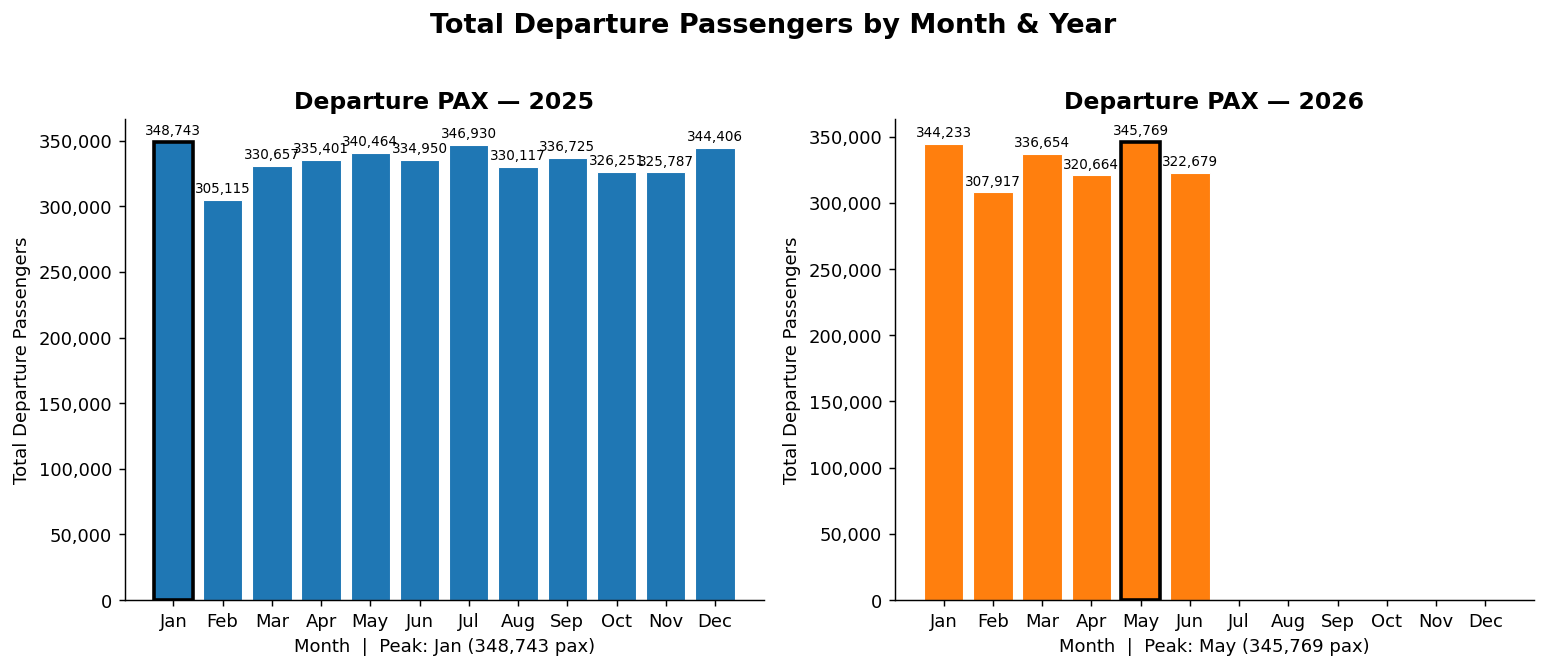

In [27]:
dep_years = sorted(df['DepYear'].unique())
arr_years = sorted(df['ArrYear'].unique())
all_years = sorted(set(dep_years) | set(arr_years))

COLORS_DEP = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
COLORS_ARR = ['#17becf','#bcbd22','#e377c2','#8c564b','#7f7f7f']

# ── Departure Passengers by Month & Year ──────────────────────────────────────
fig, axes = plt.subplots(1, len(dep_years), figsize=(6 * len(dep_years), 5), sharey=False)
if len(dep_years) == 1:
    axes = [axes]

for ax, year, color in zip(axes, dep_years, COLORS_DEP):
    sub = df[df['DepYear'] == year].copy()
    monthly = sub.groupby('DepMonth')['TotalDepPax'].sum().reindex(range(1,13), fill_value=0)
    monthly.index = MONTH_NAMES

    bars = ax.bar(monthly.index, monthly.values, color=color, edgecolor='white', linewidth=0.6)
    peak_idx = monthly.values.argmax()
    bars[peak_idx].set_edgecolor('black')
    bars[peak_idx].set_linewidth(2)

    ax.set_title(f'Departure PAX — {year}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Total Departure Passengers')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.01,
                    f'{int(h):,}', ha='center', va='bottom', fontsize=7.5)

    peak_month = monthly.idxmax()
    ax.set_xlabel(f'Month  |  Peak: {peak_month} ({int(monthly.max()):,} pax)')

fig.suptitle('Total Departure Passengers by Month & Year', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

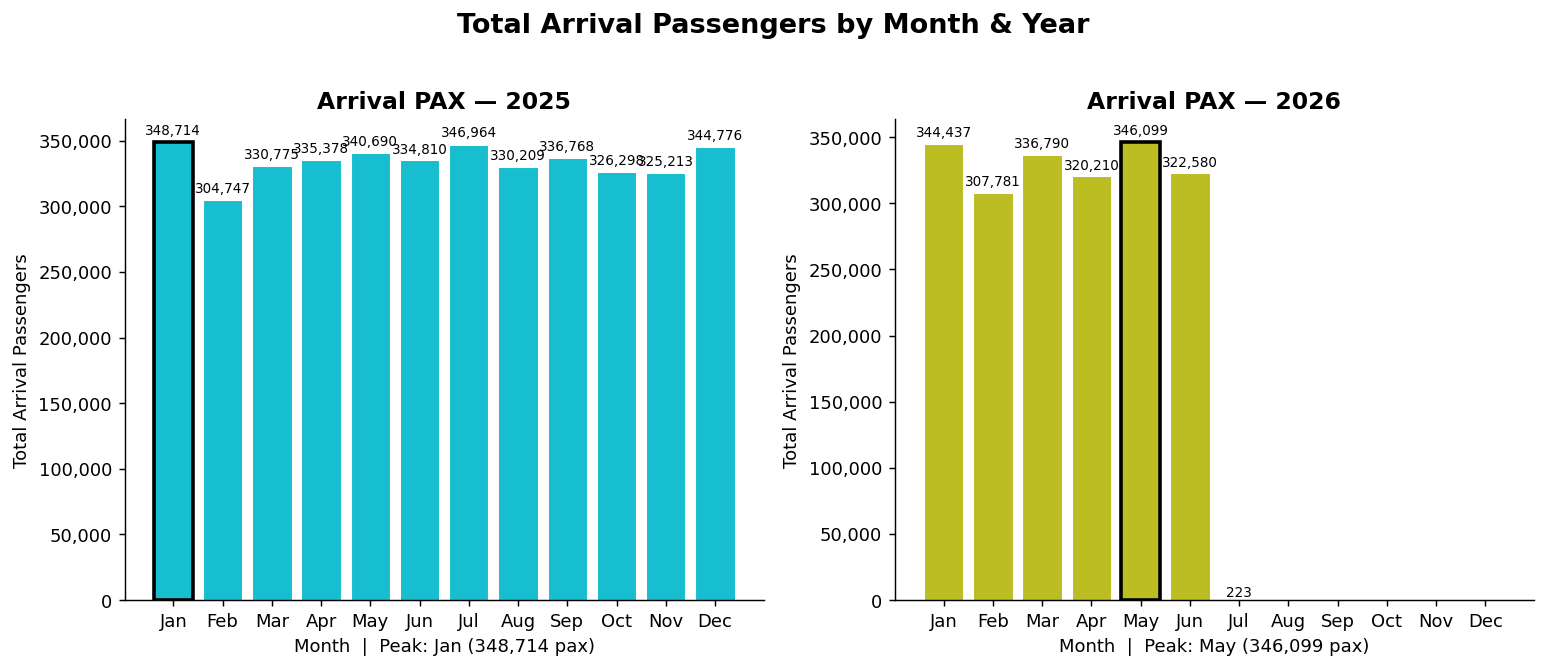

In [28]:
# ── Arrival Passengers by Month & Year ────────────────────────────────────────
fig, axes = plt.subplots(1, len(arr_years), figsize=(6 * len(arr_years), 5), sharey=False)
if len(arr_years) == 1:
    axes = [axes]

for ax, year, color in zip(axes, arr_years, COLORS_ARR):
    sub = df[df['ArrYear'] == year].copy()
    monthly = sub.groupby('ArrMonth')['TotalArrPax'].sum().reindex(range(1,13), fill_value=0)
    monthly.index = MONTH_NAMES

    bars = ax.bar(monthly.index, monthly.values, color=color, edgecolor='white', linewidth=0.6)
    peak_idx = monthly.values.argmax()
    bars[peak_idx].set_edgecolor('black')
    bars[peak_idx].set_linewidth(2)

    ax.set_title(f'Arrival PAX — {year}')
    ax.set_ylabel('Total Arrival Passengers')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.01,
                    f'{int(h):,}', ha='center', va='bottom', fontsize=7.5)

    peak_month = monthly.idxmax()
    ax.set_xlabel(f'Month  |  Peak: {peak_month} ({int(monthly.max()):,} pax)')

fig.suptitle('Total Arrival Passengers by Month & Year', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 5b. Pie Charts — LiftStatus, FlyThru & IsNTL Distribution (by Total Passengers)

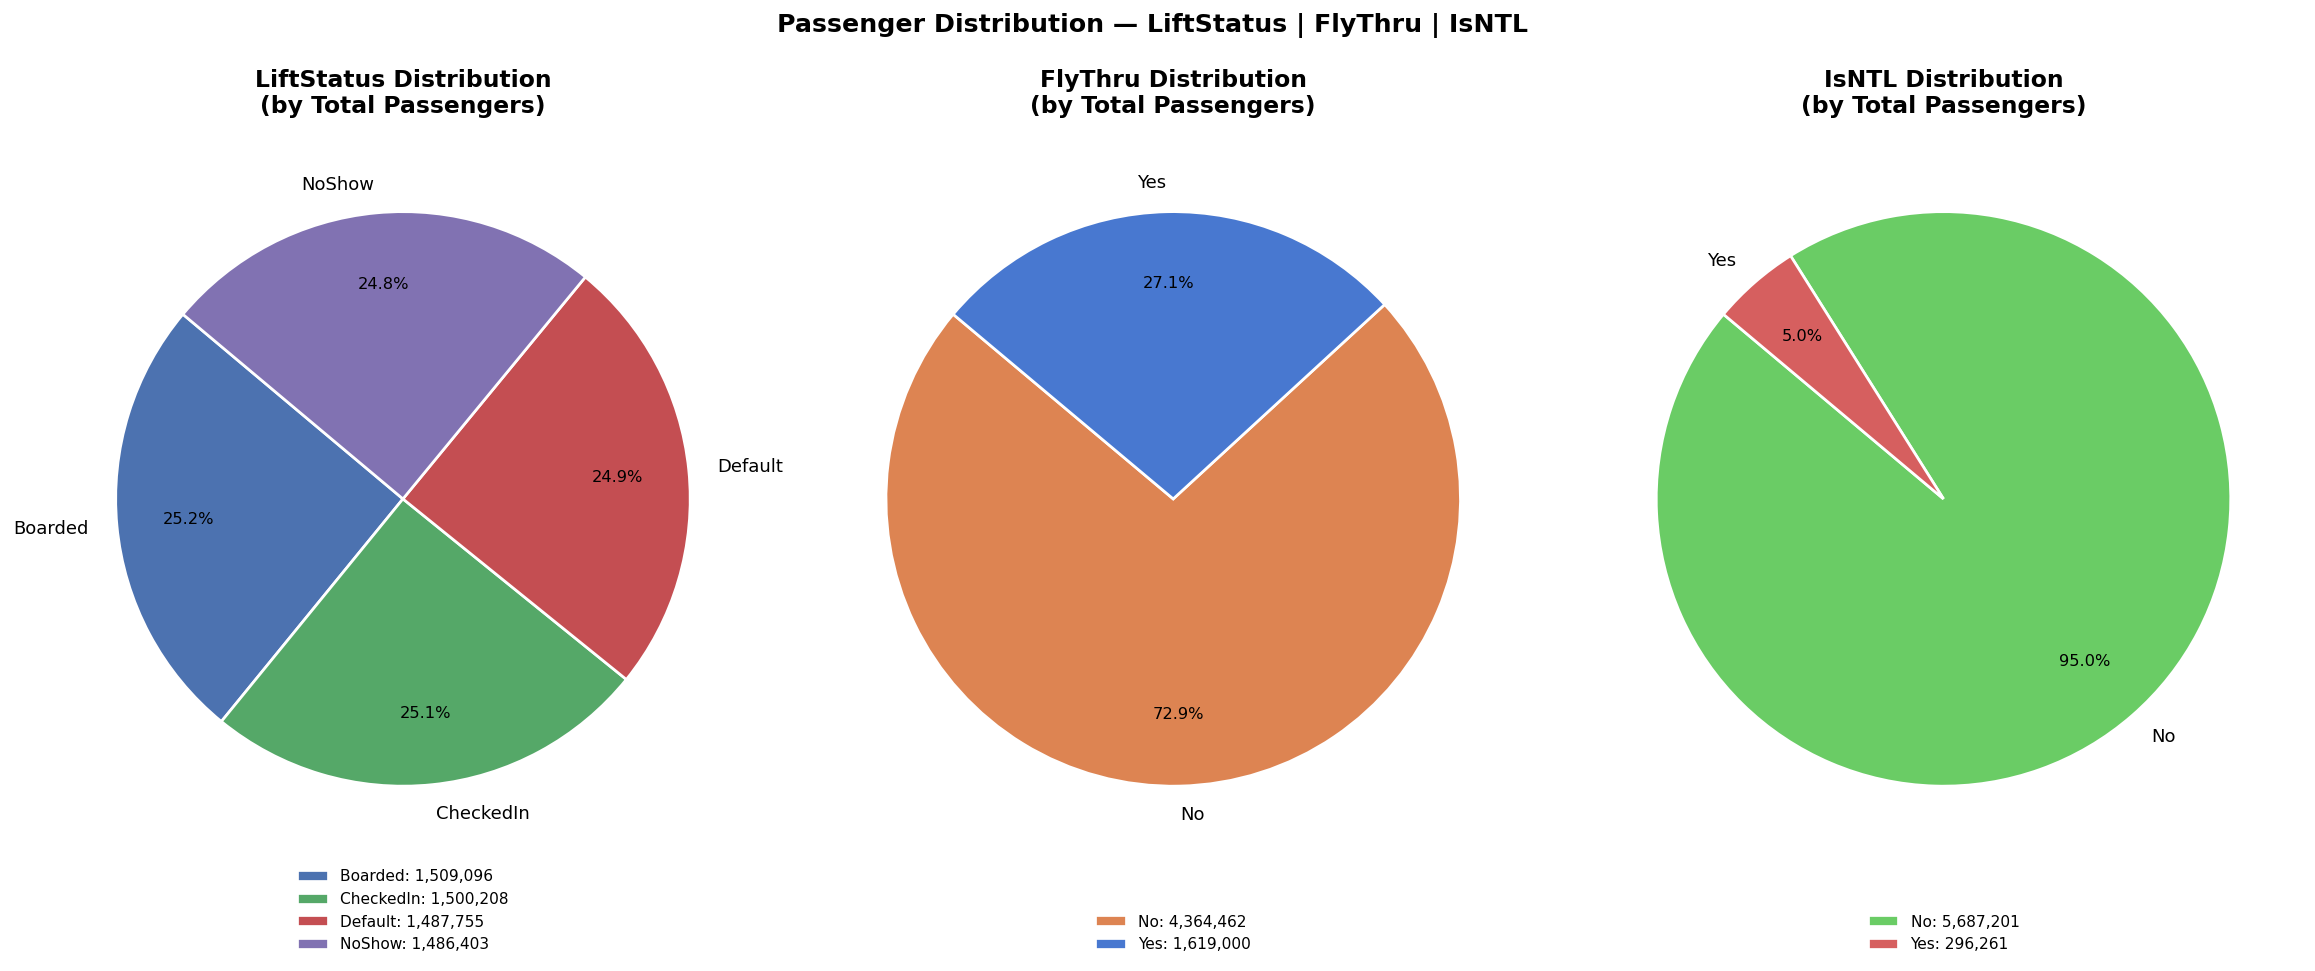

In [29]:
total_pax_col = 'TotalDepPax'   # use TotalDepPax as the weighting column for all three pie charts

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ── (i) LiftStatus ────────────────────────────────────────────────────────────
lift_pax = df.groupby('LiftStatusLabel')[total_pax_col].sum()
LIFT_COLORS = ['#4C72B0','#55A868','#C44E52','#8172B2']

wedges, texts, autotexts = axes[0].pie(
    lift_pax.values,
    labels=lift_pax.index,
    autopct='%1.1f%%',
    colors=LIFT_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts: at.set_fontsize(9)
axes[0].set_title('LiftStatus Distribution\n(by Total Passengers)', pad=15)

legend_labels = [f"{k}: {int(v):,}" for k, v in lift_pax.items()]
axes[0].legend(wedges, legend_labels, loc='lower center',
               bbox_to_anchor=(0.5, -0.15), fontsize=8.5, frameon=False)

# ── (ii) FlyThru ──────────────────────────────────────────────────────────────
flythru_pax = df.groupby('FlyThru')[total_pax_col].sum()
FT_COLORS = ['#DD8452','#4878D0']

wedges2, texts2, autotexts2 = axes[1].pie(
    flythru_pax.values,
    labels=flythru_pax.index,
    autopct='%1.1f%%',
    colors=FT_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts2: at.set_fontsize(9)
axes[1].set_title('FlyThru Distribution\n(by Total Passengers)', pad=15)

legend_labels2 = [f"{k}: {int(v):,}" for k, v in flythru_pax.items()]
axes[1].legend(wedges2, legend_labels2, loc='lower center',
               bbox_to_anchor=(0.5, -0.15), fontsize=8.5, frameon=False)

# ── (iii) IsNTL ───────────────────────────────────────────────────────────────
isntl_pax = df.groupby('IsNTL')[total_pax_col].sum()
NTL_COLORS = ['#6ACC65','#D65F5F']

wedges3, texts3, autotexts3 = axes[2].pie(
    isntl_pax.values,
    labels=isntl_pax.index,
    autopct='%1.1f%%',
    colors=NTL_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts3: at.set_fontsize(9)
axes[2].set_title('IsNTL Distribution\n(by Total Passengers)', pad=15)

legend_labels3 = [f"{k}: {int(v):,}" for k, v in isntl_pax.items()]
axes[2].legend(wedges3, legend_labels3, loc='lower center',
               bbox_to_anchor=(0.5, -0.15), fontsize=8.5, frameon=False)

fig.suptitle('Passenger Distribution — LiftStatus | FlyThru | IsNTL',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### 5c. Top 10 LegNumber by Total Departure Passengers (Horizontal Bar Chart)

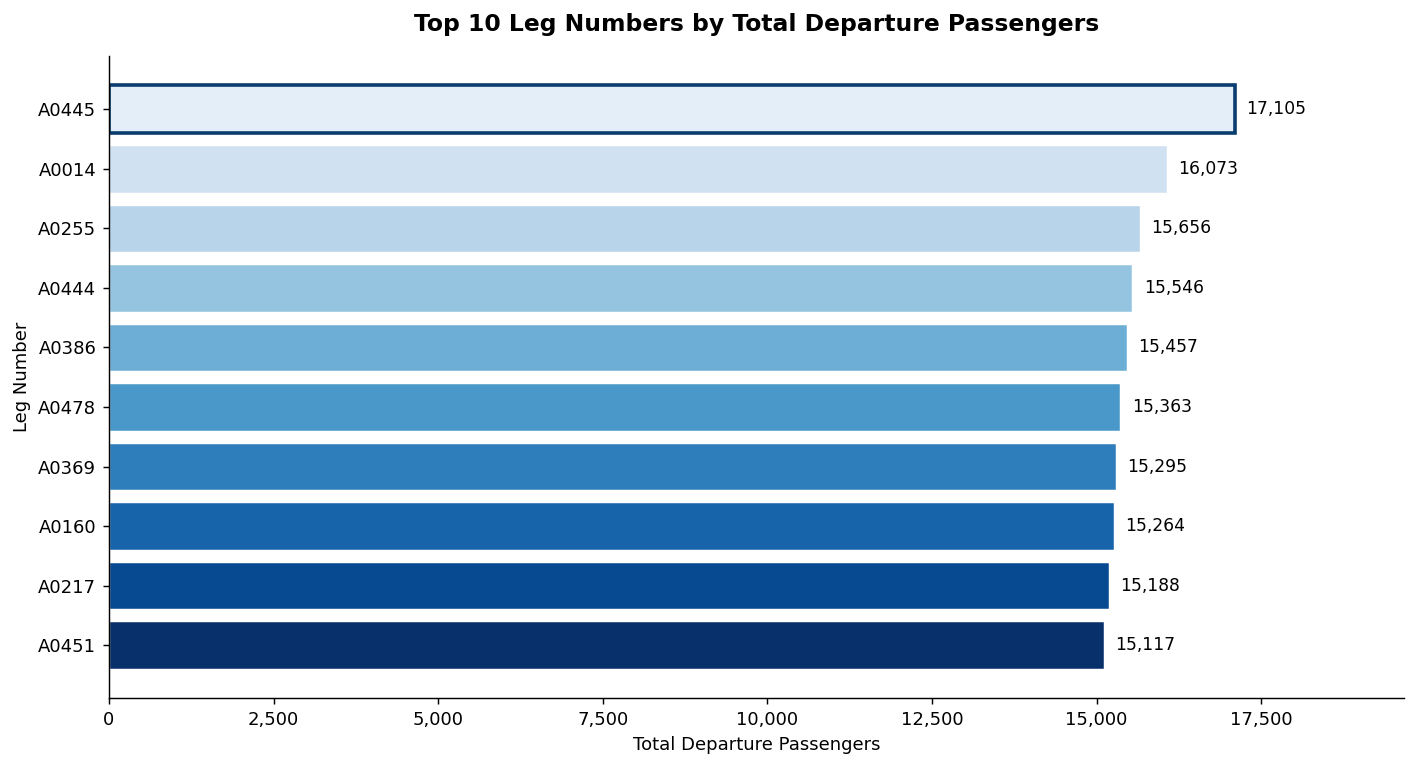

In [30]:
top10_leg = (
    df.groupby('LegNumber')['TotalDepPax']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)   # ascending so highest bar sits at top
)

fig, ax = plt.subplots(figsize=(11, 6))

colors = plt.cm.Blues_r([i / (len(top10_leg)) for i in range(len(top10_leg))])
bars = ax.barh(top10_leg.index.astype(str), top10_leg.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Highlight the top bar
bars[-1].set_edgecolor('#0a3d6e')
bars[-1].set_linewidth(2)

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + top10_leg.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=9.5)

ax.set_title('Top 10 Leg Numbers by Total Departure Passengers', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Total Departure Passengers')
ax.set_ylabel('Leg Number')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top10_leg.max() * 1.15)

plt.tight_layout()
plt.show()

##### 5d. InternationalDesc Distribution (Pie Chart)

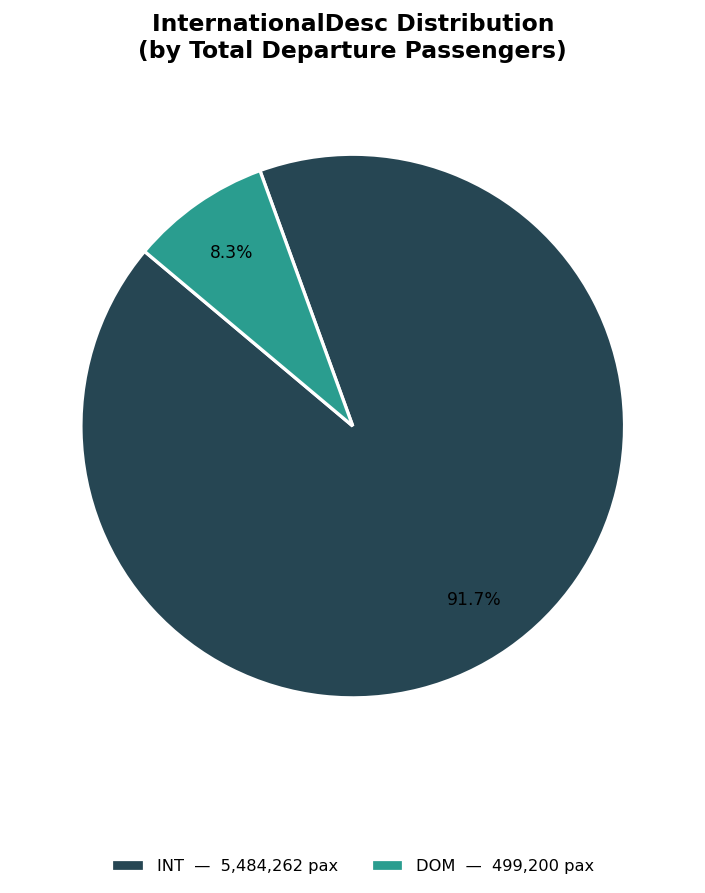

In [31]:
intl_pax = df.groupby('InternationalDesc')['TotalDepPax'].sum().sort_values(ascending=False)

INTL_COLORS = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51',
               '#457B9D','#A8DADC','#F1FAEE','#E63946','#6A4C93']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    intl_pax.values,
    labels=None,
    autopct='%1.1f%%',
    colors=INTL_COLORS[:len(intl_pax)],
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.8}
)
for at in autotexts:
    at.set_fontsize(9.5)

legend_labels = [f'{k}  —  {int(v):,} pax' for k, v in intl_pax.items()]
ax.legend(wedges, legend_labels,
          loc='lower center', bbox_to_anchor=(0.5, -0.18),
          fontsize=9, frameon=False, ncol=2)

ax.set_title('InternationalDesc Distribution\n(by Total Departure Passengers)',
             fontsize=13, fontweight='bold', pad=16)

plt.tight_layout()
plt.show()

##### 5e. Top 5 Departure Countries by Total Departure Passengers (Horizontal Bar Chart)

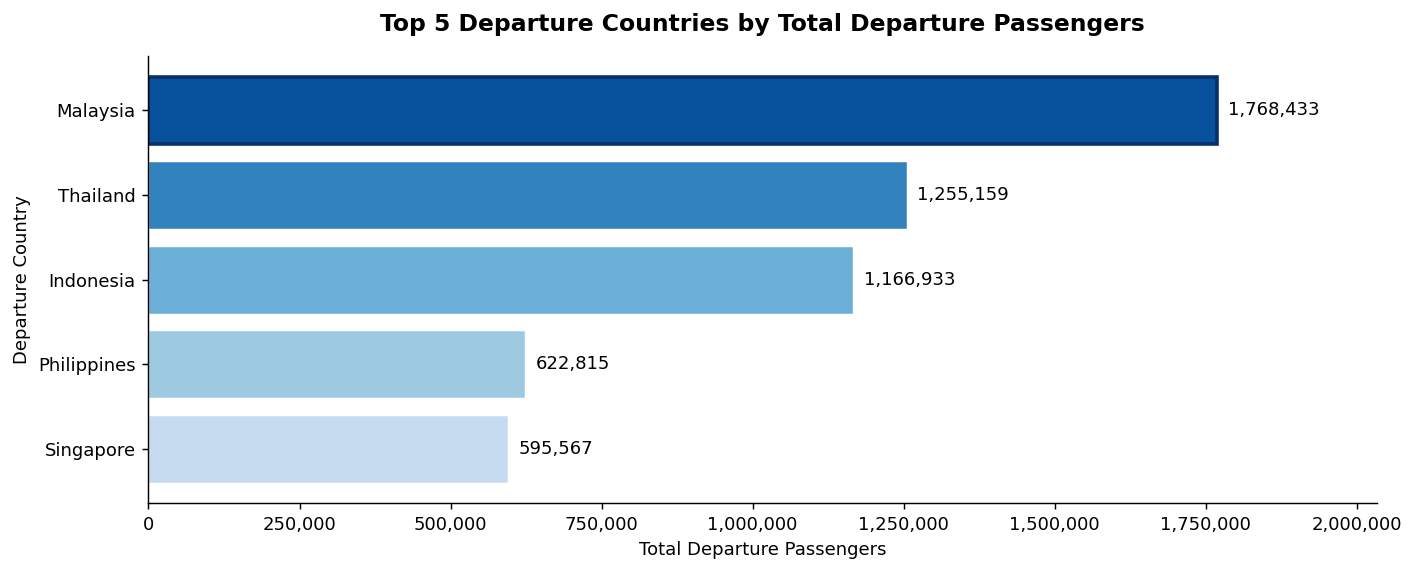

In [32]:
top5_dep_country = (
    df.groupby('DepartureCountry')['TotalDepPax']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 4.5))

dep_colors = ['#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
bars = ax.barh(top5_dep_country.index, top5_dep_country.values,
               color=dep_colors, edgecolor='white', linewidth=0.8)

bars[-1].set_edgecolor('#08306b')
bars[-1].set_linewidth(2)

for bar in bars:
    w = bar.get_width()
    ax.text(w + top5_dep_country.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=10)

ax.set_title('Top 5 Departure Countries by Total Departure Passengers',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Total Departure Passengers')
ax.set_ylabel('Departure Country')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top5_dep_country.max() * 1.15)

plt.tight_layout()
plt.show()

##### 5f. Top 5 Arrival Countries by Total Arrival Passengers (Horizontal Bar Chart)

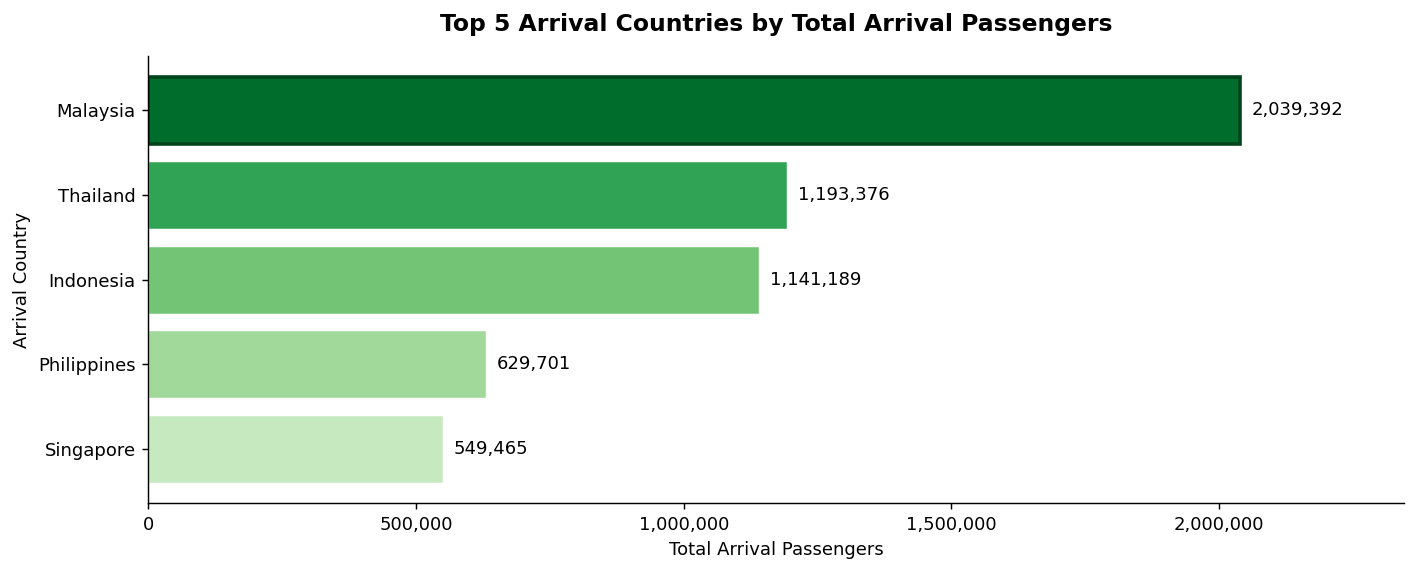

In [33]:
top5_arr_country = (
    df.groupby('ArrivalCountry')['TotalArrPax']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 4.5))

arr_colors = ['#c7e9c0','#a1d99b','#74c476','#31a354','#006d2c']
bars = ax.barh(top5_arr_country.index, top5_arr_country.values,
               color=arr_colors, edgecolor='white', linewidth=0.8)

bars[-1].set_edgecolor('#00441b')
bars[-1].set_linewidth(2)

for bar in bars:
    w = bar.get_width()
    ax.text(w + top5_arr_country.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=10)

ax.set_title('Top 5 Arrival Countries by Total Arrival Passengers',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Total Arrival Passengers')
ax.set_ylabel('Arrival Country')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top5_arr_country.max() * 1.15)

plt.tight_layout()
plt.show()